In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
plt.rcParams['font.family']='Malgun Gothic'

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score



In [2]:
cancer = load_breast_cancer(as_frame=True)
x_data = cancer['data']
y_data = cancer['target']

train, test 나누기

In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.3, random_state=42, stratify=y_data
)

정규화

In [4]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [5]:
y_train_n = np.array(y_train, np.float32)
y_test_n = np.array(y_test, np.float32)

케라스학습

In [6]:
dense = Dense(units=1, input_dim=30, activation='sigmoid')
model = Sequential([dense])
model.compile(loss='binary_crossentropy', optimizer=Adam(0.01), metrics=['acc'])
h = model.fit(x_train_s,y_train_n, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6759 - loss: 0.7357  
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8769 - loss: 0.3737 
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9296 - loss: 0.2414 
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9422 - loss: 0.1828 
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9573 - loss: 0.1447 
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9698 - loss: 0.1267 
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9799 - loss: 0.1154 
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9799 - loss: 0.1070 
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9799 - loss: 0.1006 
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0960 
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0918 
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0886 
Epoch 13/500
13/13 ━━━━━━━━━━━━━━━━━

In [7]:
train_pred = (model.predict(x_train_s)>0.5)+0
test_pred = (model.predict(x_test_s)>0.5)+0

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


confusion matrix

In [8]:
cm_train = confusion_matrix(y_train, train_pred)
print(cm_train)

[[145   3]
 [  1 249]]


In [9]:
cm_test = confusion_matrix(y_test, test_pred)
print(cm_test)

[[ 60   4]
 [  0 107]]


heat map

Text(0.5, 1.0, 'Test')

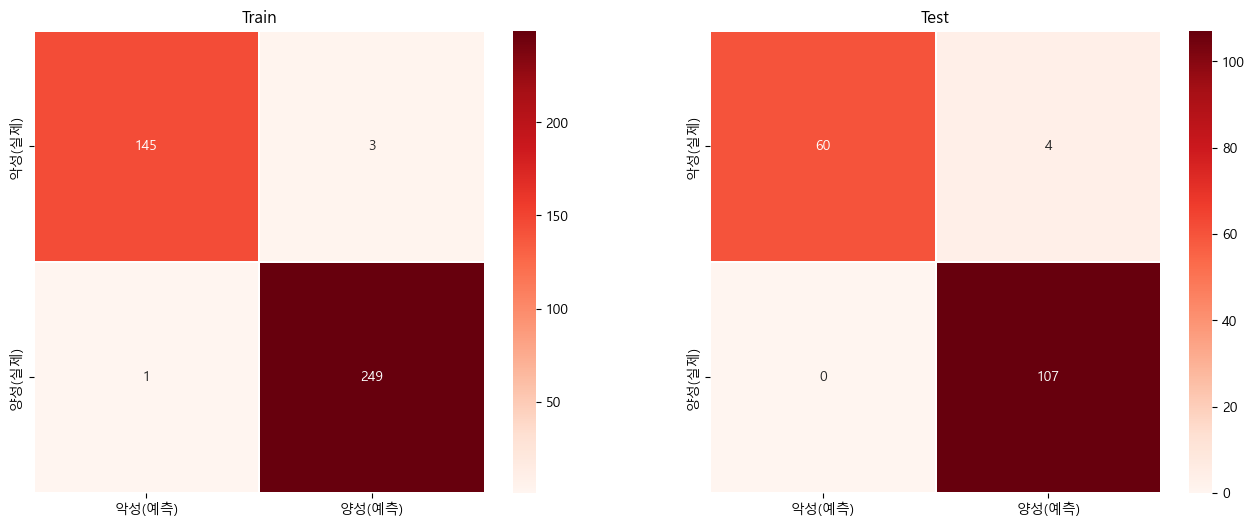

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sb.heatmap(cm_train,
        annot=True,        # 숫자 표시 여부
        fmt='d',           # 정수(decimal)로 표시 (안 쓰면 지수 형태 3.1e+2 로 나옴)
        linewidths=0.2,    # 칸 사이 간격
        cmap='Reds',       # 색상 테마
        xticklabels=['악성(예측)', '양성(예측)'], 
        yticklabels=['악성(실제)', '양성(실제)'],
        ax=ax[0]
)
ax[0].set_title('Train')

sb.heatmap(cm_test,
        annot=True,        # 숫자 표시 여부
        fmt='d',           # 정수(decimal)로 표시 (안 쓰면 지수 형태 3.1e+2 로 나옴)
        linewidths=0.2,    # 칸 사이 간격
        cmap='Reds',       # 색상 테마
        xticklabels=['악성(예측)', '양성(예측)'], 
        yticklabels=['악성(실제)', '양성(실제)'],
        ax=ax[1]
)
ax[1].set_title('Test')

f1, acc

In [11]:
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

print('F1 Score(Train) : ', train_f1)
print('F1 Score(Test) : ', test_f1)

F1 Score(Train) :  0.9920318725099602
F1 Score(Test) :  0.981651376146789


acc

In [12]:
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test,  test_pred)

print("Accuracy(Train):", train_acc)
print("Accuracy(Test) :", test_acc)

Accuracy(Train): 0.9899497487437185
Accuracy(Test) : 0.9766081871345029


In [13]:
h.history['acc'][-1]

0.9899497628211975

1번째행 예측값

In [24]:
xd = scaler.transform( x_data.iloc[0].values.reshape(1,-1) )
(model.predict( xd) >0.5) + 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


c:\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0]])